In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [244]:
df = pd.read_csv('/content/drug.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


**Data Wrangling**

In [245]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [246]:
df.duplicated().sum()

np.int64(0)

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [248]:
df_categorical = df.select_dtypes(['object']).columns
df_categorical

Index(['Sex', 'BP', 'Cholesterol', 'Drug'], dtype='object')

In [249]:
df_numerical = df.select_dtypes(['int64','float64']).columns
df_numerical

Index(['Age', 'Na_to_K'], dtype='object')

In [250]:
# Converting categorical columns to numeric

In [251]:
# Sex

In [252]:
df['Sex'].value_counts()

,count
Sex,
M,104
F,96


In [253]:
df['Sex'] = df['Sex'].map({'M':0,'F':1})
df['Sex']

,Sex
0,1
1,0
2,0
3,1
4,1
...,...
195,1
196,0
197,0
198,0


In [254]:
# BP

In [255]:
df['BP'].value_counts()

,count
BP,
HIGH,77
LOW,64
NORMAL,59


In [256]:
# cholestrol

In [257]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
HIGH,103
NORMAL,97


In [258]:
from sklearn.preprocessing import LabelEncoder

for col in df[['BP', 'Cholesterol']]:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])

In [259]:
# Drug

In [260]:
df['Drug'].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


In [261]:
from sklearn.preprocessing import LabelEncoder

df['Drug'] = df['Drug'].map({'drugA':0,'drugB':1,'drugC':2,'drugX':3,'DrugY':4})
df['Drug']

,Drug
0,4
1,2
2,2
3,3
4,4
...,...
195,2
196,2
197,3
198,3


In [262]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,0,25.355,4
1,47,0,1,0,13.093,2
2,47,0,1,0,10.114,2
3,28,1,2,0,7.798,3
4,61,1,1,0,18.043,4


In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


#**EDA**

In [266]:
df.corr()['Drug']

,Drug
Age,-0.004828
Sex,0.098573
BP,0.372868
Cholesterol,0.055629
Na_to_K,0.589120
Drug,1.000000


Text(0, 0.5, 'Correlation with Drug')

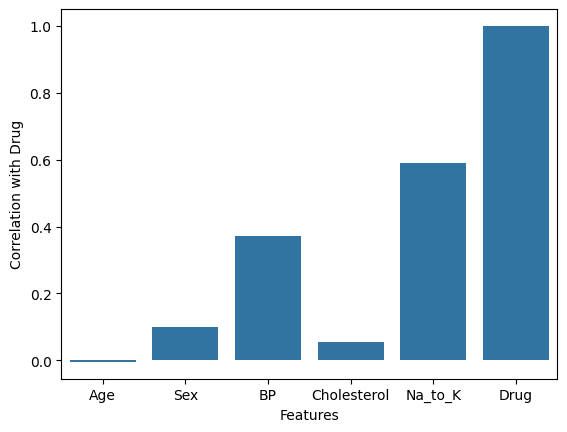

In [269]:
sns.barplot( x = df.corr()['Drug'].index,y = df.corr()['Drug'].values)
plt.xlabel('Features')
plt.ylabel('Correlation with Drug')

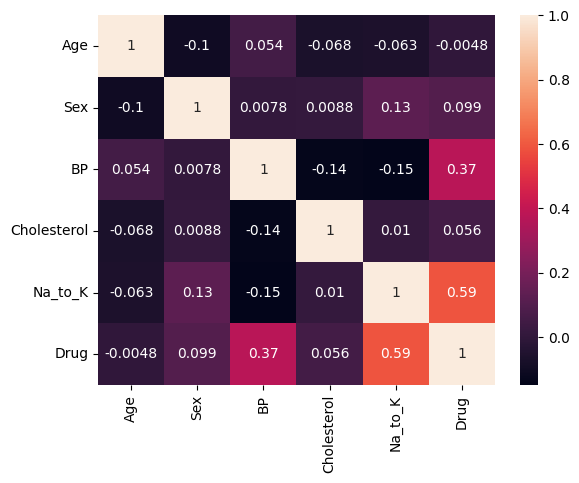

In [270]:
# Heat Map

sns.heatmap(df.corr(),annot=True)
plt.show()

<Figure size 1500x800 with 0 Axes>

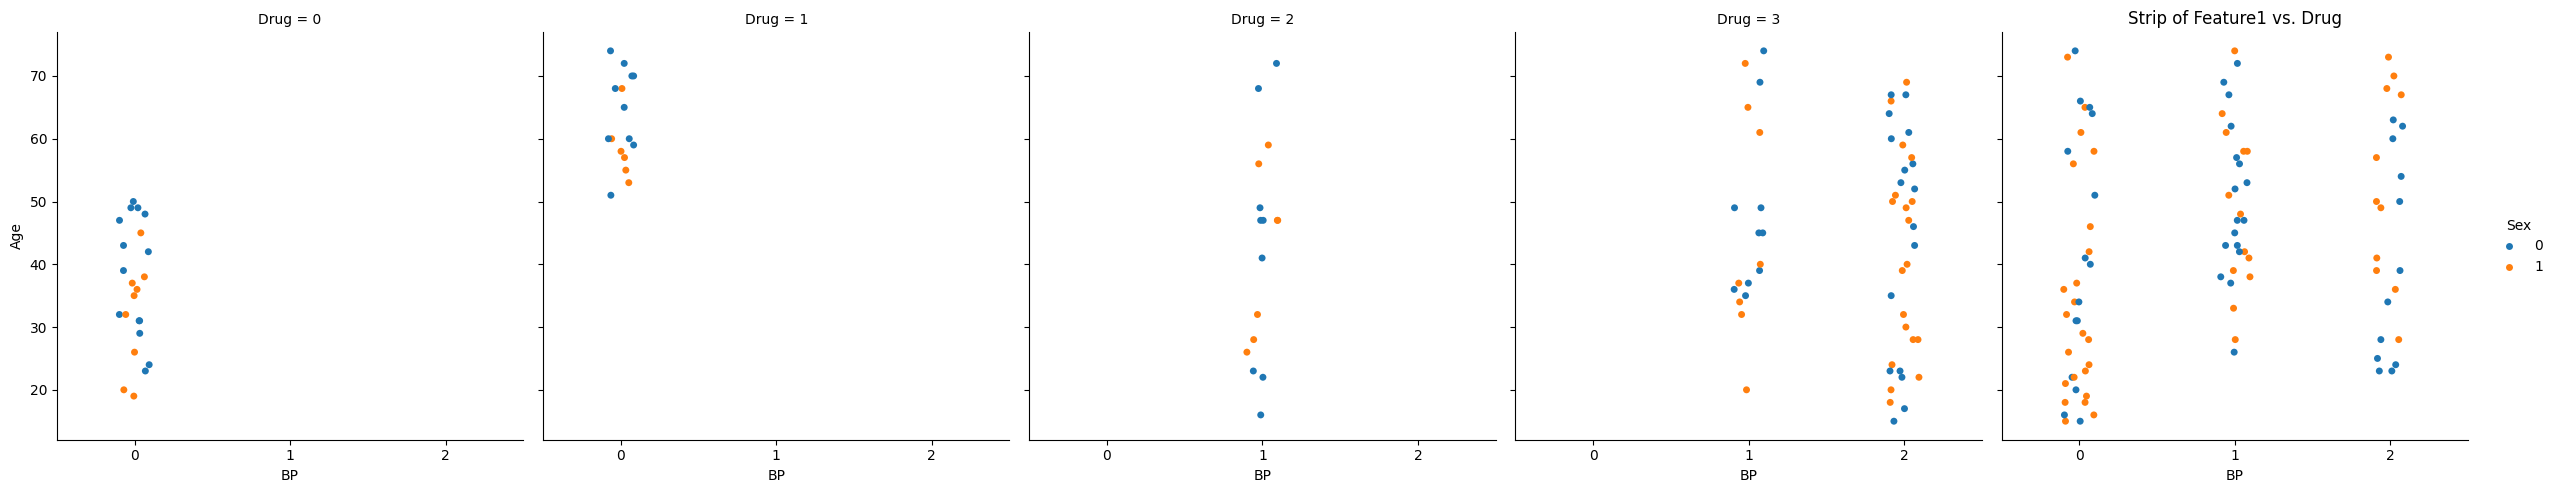

In [305]:
# Create the boxplot
plt.figure(figsize=(15, 8))
sns.catplot(x='BP', y='Age', col= 'Drug', data=df, kind='strip',hue='Sex')  # Example: Boxplot of Feature1 vs. Drug
plt.title('Strip of Feature1 vs. Drug')
plt.show()

#**Model Building**

In [271]:
x = df.drop('Drug',axis=1)
y = df['Drug']

In [272]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [273]:
x_train.shape,y_train.shape

((160, 5), (160,))

In [274]:
x_train.shape,x_test.shape

((160, 5), (40, 5))

In [275]:
# SVC

In [276]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(x_train,y_train)

SVC()

In [277]:
pred = svc.predict(x_test)
pred

array([3, 4, 3, 3, 4, 4, 4, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 4, 3, 3,
       3, 4, 4, 4, 3, 3, 4, 3, 4, 3, 4, 4, 3, 4, 4, 3, 4, 3])

# **Evaluation**

In [278]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

In [279]:
accuracy_score = accuracy_score(y_test,pred)
accuracy_score

0.625

In [280]:
cm = confusion_matrix(y_test,pred)
cm

array([[ 0,  0,  0,  6,  0],
       [ 0,  0,  0,  3,  0],
       [ 0,  0,  0,  4,  1],
       [ 0,  0,  0, 10,  1],
       [ 0,  0,  0,  0, 15]])

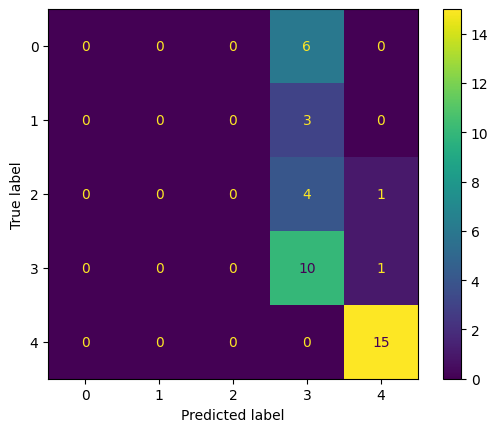

In [281]:
display = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = svc.classes_)
display.plot()

In [282]:
# Classification report

classification_rep = classification_report(y_test,pred)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         5
           3       0.43      0.91      0.59        11
           4       0.88      1.00      0.94        15

    accuracy                           0.62        40
   macro avg       0.26      0.38      0.31        40
weighted avg       0.45      0.62      0.51        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#**Hyperparameter Tunnings**

In [283]:
from sklearn.model_selection import RandomizedSearchCV

parameter = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.1, 1],  # Kernel coefficient
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  # Kernel type
    'degree': [2, 3, 4],  # Degree of the polynomial kernel (only used if kernel='poly')
    'coef0': [0, 1], # Independent term in kernel function (only used if kernel='poly')
    'shrinking': [True, False] # Use shrinking to speed up training (only used if kernel='rbf')
}


In [284]:
random_search = RandomizedSearchCV(
    estimator=svc,
    param_distributions=parameter,
    n_iter=10,  # Number of parameter combinations to try
    scoring='accuracy',  # Evaluation metric
    cv=5,  # Cross-validation folds
    random_state=42,  # Set random_state for reproducibility
    n_jobs=-1  # Use all available cores for parallel processing
)


In [285]:
random_search.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10, 100], 'coef0': [0, 1],
                                        'degree': [2, 3, 4],
                                        'gamma': ['scale', 'auto', 0.1, 1],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid'],
                                        'shrinking': [True, False]},
                   random_state=42, scoring='accuracy')

In [286]:
print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

Best parameters: {'shrinking': True, 'kernel': 'linear', 'gamma': 0.1, 'degree': 3, 'coef0': 0, 'C': 100}
Best score: 0.9875


In [287]:
# You can also access the best model:
best_model = random_search.best_estimator_

# Make predictions with the best model
y_pred = best_model.predict(x_test)

print(best_model)
print(y_pred)


SVC(C=100, coef0=0, gamma=0.1, kernel='linear')
[3 4 3 2 4 4 4 3 0 3 0 3 4 0 1 4 1 3 2 4 1 3 3 4 4 4 2 3 4 3 4 2 2 4 0 4 3
 0 4 0]


In [288]:
# Classification report

In [289]:
classification_rep = classification_report(y_test, y_pred)
print(classification_rep)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        15

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [290]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]


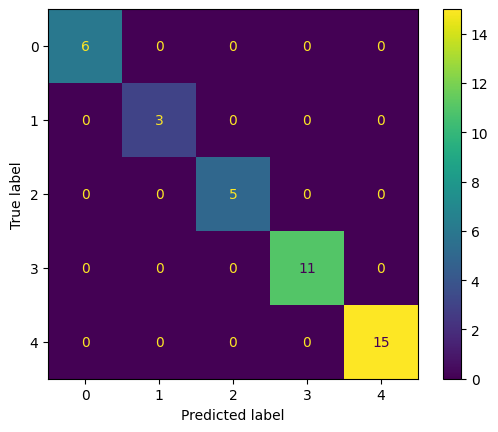

In [291]:
#Display

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svc.classes_)
display.plot()